Metodologia porównania wzorowana na *Gonçalves et al. „Comparing and combining sentiment analysis methods" (COSN 2013)*:
- **Prediction Performance** — Precision, Recall, F1, Accuracy *(cf. Table 5)*
- **F1 per aspekt** — skuteczność per aspekt *(cf. Table 6)*
- **Agreement** — zgodność między metodami *(cf. Table 4)*
- **Coverage** — odsetek aktywnych predykcji *(cf. Figure 1, 4)*
- **Macierze pomyłek** — rozkład błędów per klasa

In [4]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    accuracy_score,
)
from pathlib import Path

from config.global_config import TRAIN_ASPECTS, SENTIMENT_LABELS, ModelType
from predictions.predict_dataset import predict_dataset
from predictions.eval_align import narrow_eval_to_common_rows

ASPECTS = TRAIN_ASPECTS

CACHE_DIR = Path("statics/prediction_cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)
TEST_PATH = "statics/datasets/validate.csv"

def flat(df):
    """Spłaszcza aspekty z DataFrame do jednego wektora etykiet (str).

    Po wczytaniu predykcji z CSV puste komórki są NaN (float); sklearn wymaga
    jednorodnych etykiet, więc normalizujemy do stringów jak w ground truth.
    """
    parts = []
    for a in ASPECTS:
        s = df[a].replace("", np.nan).fillna("notmentioned").astype(str)
        parts.append(s.to_numpy())
    return np.concatenate(parts)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
df = pd.read_csv(TEST_PATH)
for a in ASPECTS:
    df[a] = df[a].fillna("notmentioned")

gt = df[["text"] + ASPECTS].copy()
print(f"Zbiór: {len(gt)} recenzji × {len(ASPECTS)} aspektów = {len(gt) * len(ASPECTS)} etykiet\n")
gt[ASPECTS].apply(pd.Series.value_counts).T.fillna(0).astype(int).reindex(columns=SENTIMENT_LABELS)

Zbiór: 970 recenzji × 8 aspektów = 7760 etykiet



,positive,neutral,negative,notmentioned
safety,13,1,15,941
cleanliness,40,0,15,915
infrastructure,137,24,80,729
nature,228,6,4,732
attractions,416,17,29,508
heritage,126,6,6,832
costs,32,7,47,884
other,586,129,100,154


In [ ]:
from tqdm import tqdm
import os
import pandas as pd
from typing import Callable

from config.global_config import ModelType, TRAIN_ASPECTS

USE_CACHE = False

# (ModelType, use_cache) — drugi element: czy wczytywać z prediction_cache
METHODS: dict[str, tuple[ModelType, bool]] = {
    "Fine-tuned DISTILBERT": (ModelType.FINE_TUNED_DISTILBERT_SST, False),
    "Fine-tuned BERT": (ModelType.FINE_TUNED_BERT, True),
    "TF-IDF": (ModelType.TFIDF_LSA, True),
    # "TF-IDF + Random Forest": (ModelType.TFIDF_LSA_RF, True),
}



def handle_progress(model_name: str):
    pbar = None

    def update_callback(progress, total):
        nonlocal pbar
        
        if pbar is None:
            pbar = tqdm(total=total, desc=f"[{model_name}]", unit="it")
        
        pbar.n = progress
        pbar.refresh()

        if progress >= total:
            pbar.close()

    return update_callback



# Cacheujemy wyniki, w celu wydajności kolejnych uruchomień
class Cache:
    def __init__(self, dir: str):
        self.cache = {}
        self.dir = dir

    def get_or_set(
        self, key: str, fn: Callable[[], pd.DataFrame], *, use_cache: bool
    ) -> pd.DataFrame:
        os.makedirs(self.dir, exist_ok=True)
        path = os.path.join(self.dir, f"{key}.csv")

        if os.path.exists(path) and use_cache:
            print(f"[{key}] Loading from cache...")
            df = pd.read_csv(path)
        else:
            print(f"[{key}] Running model inference...")
            df = fn()
            df.to_csv(path, index=False)

        return df

cache = Cache(CACHE_DIR)
preds = {}
for name, (mtype, use_cache) in METHODS.items():
    mkey = mtype.value if isinstance(mtype, ModelType) else str(mtype)
    preds[name] = cache.get_or_set(
        f"{mkey}_{name}",
        lambda m=mtype, n=name: predict_dataset(
            gt.drop(columns=TRAIN_ASPECTS), m, on_progress=handle_progress(n)
        ),
        use_cache=use_cache,
    )

gt, preds = narrow_eval_to_common_rows(gt, preds)

[fine_tuned_distilbert_sst_Fine-tuned DISTILBERT] Loading from cache...
[fine_tuned_bert_Fine-tuned BERT] Loading from cache...
[tfidf_lsa_TF-IDF] Loading from cache...
[test_bert_base_uncased_absa_test_bert-base-uncased_absa.pt] Running model inference...


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 16348.24it/s]
DistilBertModel LOAD REPORT from: distilbert-base-uncased-finetuned-sst-2-english
Key                   | Status     |  | 
----------------------+------------+--+-
classifier.bias       | UNEXPECTED |  | 
pre_classifier.bias   | UNEXPECTED |  | 
pre_classifier.weight | UNEXPECTED |  | 
classifier.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
[test_bert-base-uncased_absa.pt]: 100%|██████████| 970/970 [00:07<00:00, 125.57it/s]


## 1. Wydajność modelu
*Table 5 —*

Metryki obliczone na łącznej puli etykiet (recenzja × aspekt), traktując każdy aspekt jako osobne zadanie klasyfikacji 4-klasowej (positive / neutral / negative / notmentioned).

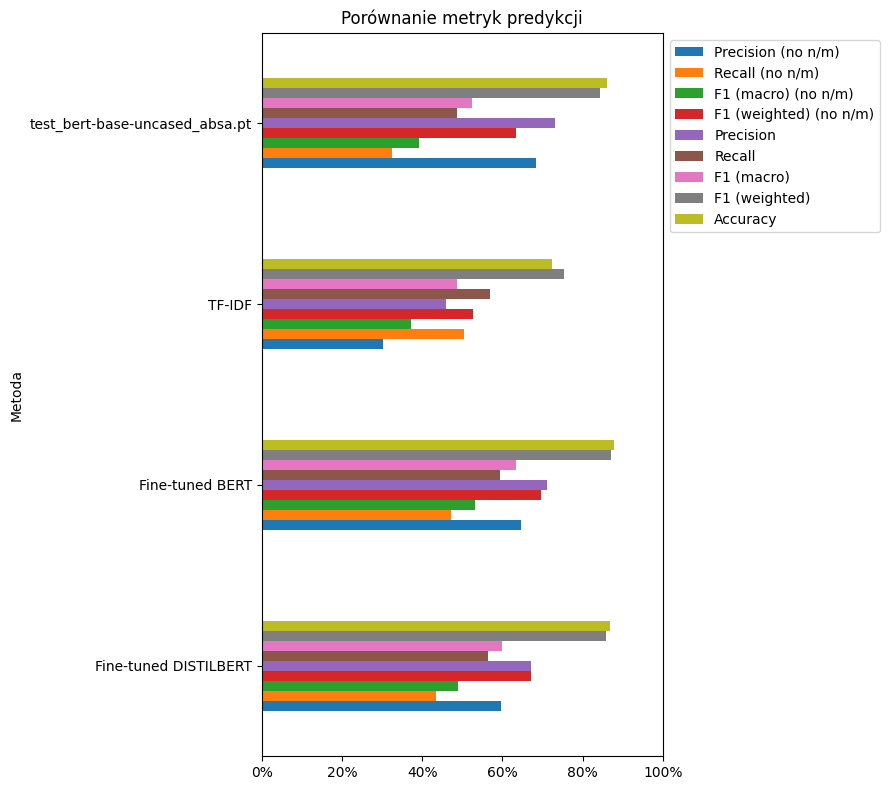

,Precision (no n/m),Recall (no n/m),F1 (macro) (no n/m),F1 (weighted) (no n/m),Precision,Recall,F1 (macro),F1 (weighted),Accuracy
Metoda,,,,,,,,,
Fine-tuned DISTILBERT,0.596,0.435,0.490,0.672,0.672,0.565,0.599,0.859,0.869
Fine-tuned BERT,0.646,0.471,0.532,0.697,0.712,0.593,0.633,0.871,0.879
TF-IDF,0.301,0.505,0.372,0.528,0.459,0.568,0.488,0.754,0.725
test_bert-base-uncased_absa.pt,0.683,0.325,0.392,0.634,0.730,0.486,0.523,0.842,0.861


In [7]:
rows = []
sentiment_no_notmentioned = [label for label in SENTIMENT_LABELS if label != "notmentioned"]

for name, p in preds.items():
    yt, yp = flat(gt), flat(p)
    rows.append({
        "Metoda": name,
        "Precision (no n/m)": precision_score(yt, yp, labels=sentiment_no_notmentioned, average="macro", zero_division=0),
        "Recall (no n/m)": recall_score(yt, yp, labels=sentiment_no_notmentioned, average="macro", zero_division=0),
        "F1 (macro) (no n/m)": f1_score(yt, yp, labels=sentiment_no_notmentioned, average="macro", zero_division=0),
        "F1 (weighted) (no n/m)": f1_score(yt, yp, labels=sentiment_no_notmentioned, average="weighted", zero_division=0),
        "Precision": precision_score(yt, yp, labels=SENTIMENT_LABELS, average="macro", zero_division=0),
        
        "Recall": recall_score(yt, yp, labels=SENTIMENT_LABELS, average="macro", zero_division=0),
        "F1 (macro)": f1_score(yt, yp, labels=SENTIMENT_LABELS, average="macro", zero_division=0),
        "F1 (weighted)": f1_score(yt, yp, labels=SENTIMENT_LABELS, average="weighted", zero_division=0),
        
        "Accuracy": accuracy_score(yt, yp),
    })

perf = pd.DataFrame(rows).set_index("Metoda")

fig, ax = plt.subplots(figsize=(9, max(len(preds) * 2, 1)))

perf.plot.barh(ax=ax)

# Ustaiwienie żeby wyświetlało się 0% i 100%
ax.set_xlim(0, 1)

ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))

ax.set_title("Porównanie metryk predykcji")
ax.legend(bbox_to_anchor=(1, 1), loc="upper left")

plt.tight_layout()
plt.show()

perf.style.format("{:.3f}")

In [8]:
from sklearn.metrics import classification_report

print(classification_report(yt, yp, digits=3))

              precision    recall  f1-score   support

    negative      0.721     0.270     0.393       296
     neutral      0.500     0.016     0.031       190
notmentioned      0.871     0.968     0.917      5695
    positive      0.829     0.689     0.752      1578
  positive        0.000     0.000     0.000         1

    accuracy                          0.861      7760
   macro avg      0.584     0.389     0.419      7760
weighted avg      0.848     0.861     0.842      7760



/Users/bartoszbugla/projects/projekt-magisterski/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/bartoszbugla/projects/projekt-magisterski/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/bartoszbugla/projects/projekt-magisterski/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to contr

In [9]:
from sklearn.metrics import f1_score

# Define only the active sentiment labels
sentiment_labels = ["positive", "neutral", "negative"]

# Calculate Macro F1 strictly for sentiments
sentiment_f1 = f1_score(
    yt, yp, 
    labels=sentiment_labels, 
    average="weighted", 
    zero_division=0
)

print(f"Sentiment-Only F1 (Macro): {sentiment_f1:.3f}")

Sentiment-Only F1 (Macro): 0.634


In [10]:
# Create binary lists: 1 if mentioned (pos/neg/neu), 0 if notmentioned
yt_binary = [0 if label == "notmentioned" else 1 for label in yt]
yp_binary = [0 if label == "notmentioned" else 1 for label in yp]

# Evaluate Aspect Detection
detection_f1 = f1_score(yt_binary, yp_binary, average="binary")
print(f"Aspect Detection F1: {detection_f1:.3f}")

Aspect Detection F1: 0.715


## 2. F1-score per aspekt
*Table 6*

F1 macro dla każdej kombinacji (metoda × aspekt) — pozwala zidentyfikować, które aspekty są najtrudniejsze dla poszczególnych metod.

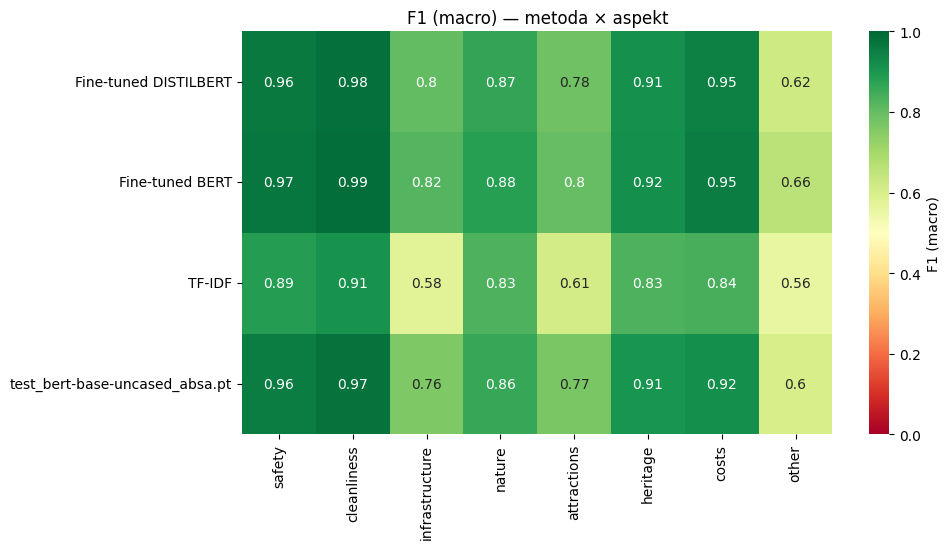

In [11]:
color_map = sns.color_palette("RdYlGn", as_cmap=True)

f1_asp = pd.DataFrame({
    name: {a: f1_score(gt[a], p[a], labels=SENTIMENT_LABELS, average="weighted", zero_division=0) for a in ASPECTS}
    for name, p in preds.items()
}).T

fig, ax = plt.subplots(figsize=(10, max(len(preds) * 1.4, 2.5)))
sns.heatmap(
    f1_asp, annot=True, cmap=color_map, vmin=0, vmax=1, ax=ax, cbar_kws={"label": "F1 (macro)"},
)
ax.set_title("F1 (macro) — metoda × aspekt")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 3. Agreement między metodami
*Table 4*

Odsetek par (recenzja × aspekt) dla których dwie metody przewidziały **identyczny** sentyment. Wysoka zgodność wzmacnia zaufanie do klasyfikacji; niska wskazuje, że metody interpretują tekst odmiennie.

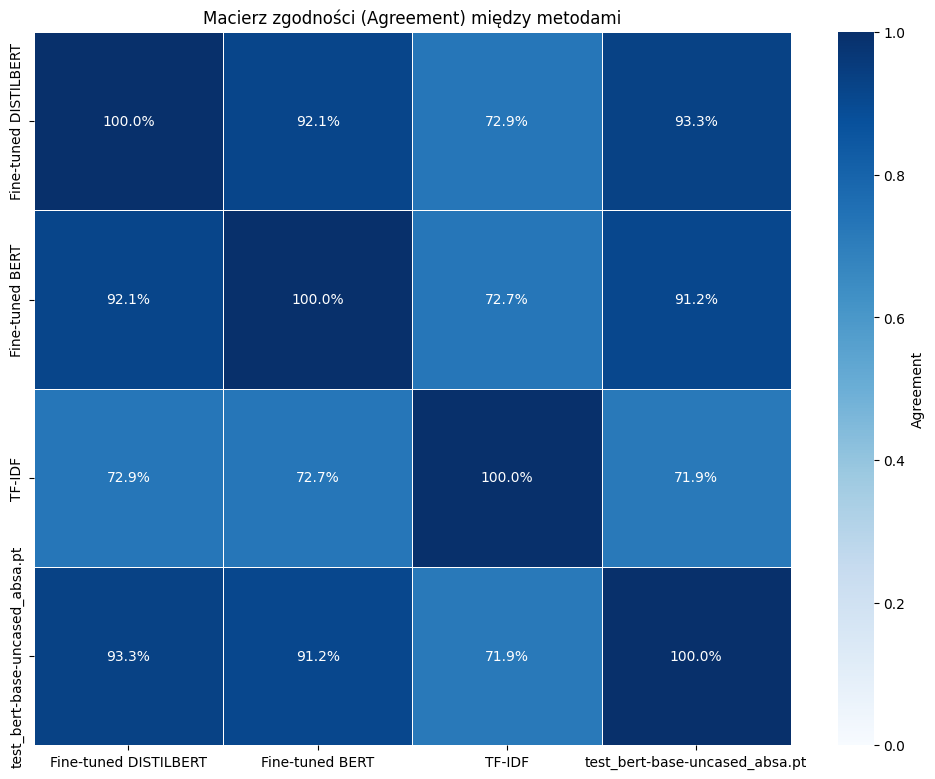

In [12]:
names = list(preds.keys())
agr = pd.DataFrame(
    [[(flat(preds[a]) == flat(preds[b])).mean() if i != j else 1.0
      for j, b in enumerate(names)]
     for i, a in enumerate(names)],
    index=names, columns=names,
)

fig, ax = plt.subplots(figsize=(max(len(names) * 2.5, 5), max(len(names) * 2, 4)))
sns.heatmap(
    agr, annot=True, fmt=".1%", cmap="Blues", vmin=0, vmax=1,
    linewidths=0.5, ax=ax, cbar_kws={"label": "Agreement"},
)
ax.set_title("Macierz zgodności (Agreement) między metodami")
plt.tight_layout()
plt.show()

## 4. Coverage
*Figure 1 & Figure 4(a)*

Coverage = odsetek predykcji **różnych od `notmentioned`**. Niska wartość oznacza, że metoda nie wykrywa sentymentu i klasyfikuje większość par (recenzja × aspekt) jako niewspomniany. Jest to odpowiednik „fraction of messages whose sentiment is identified" z artykułu

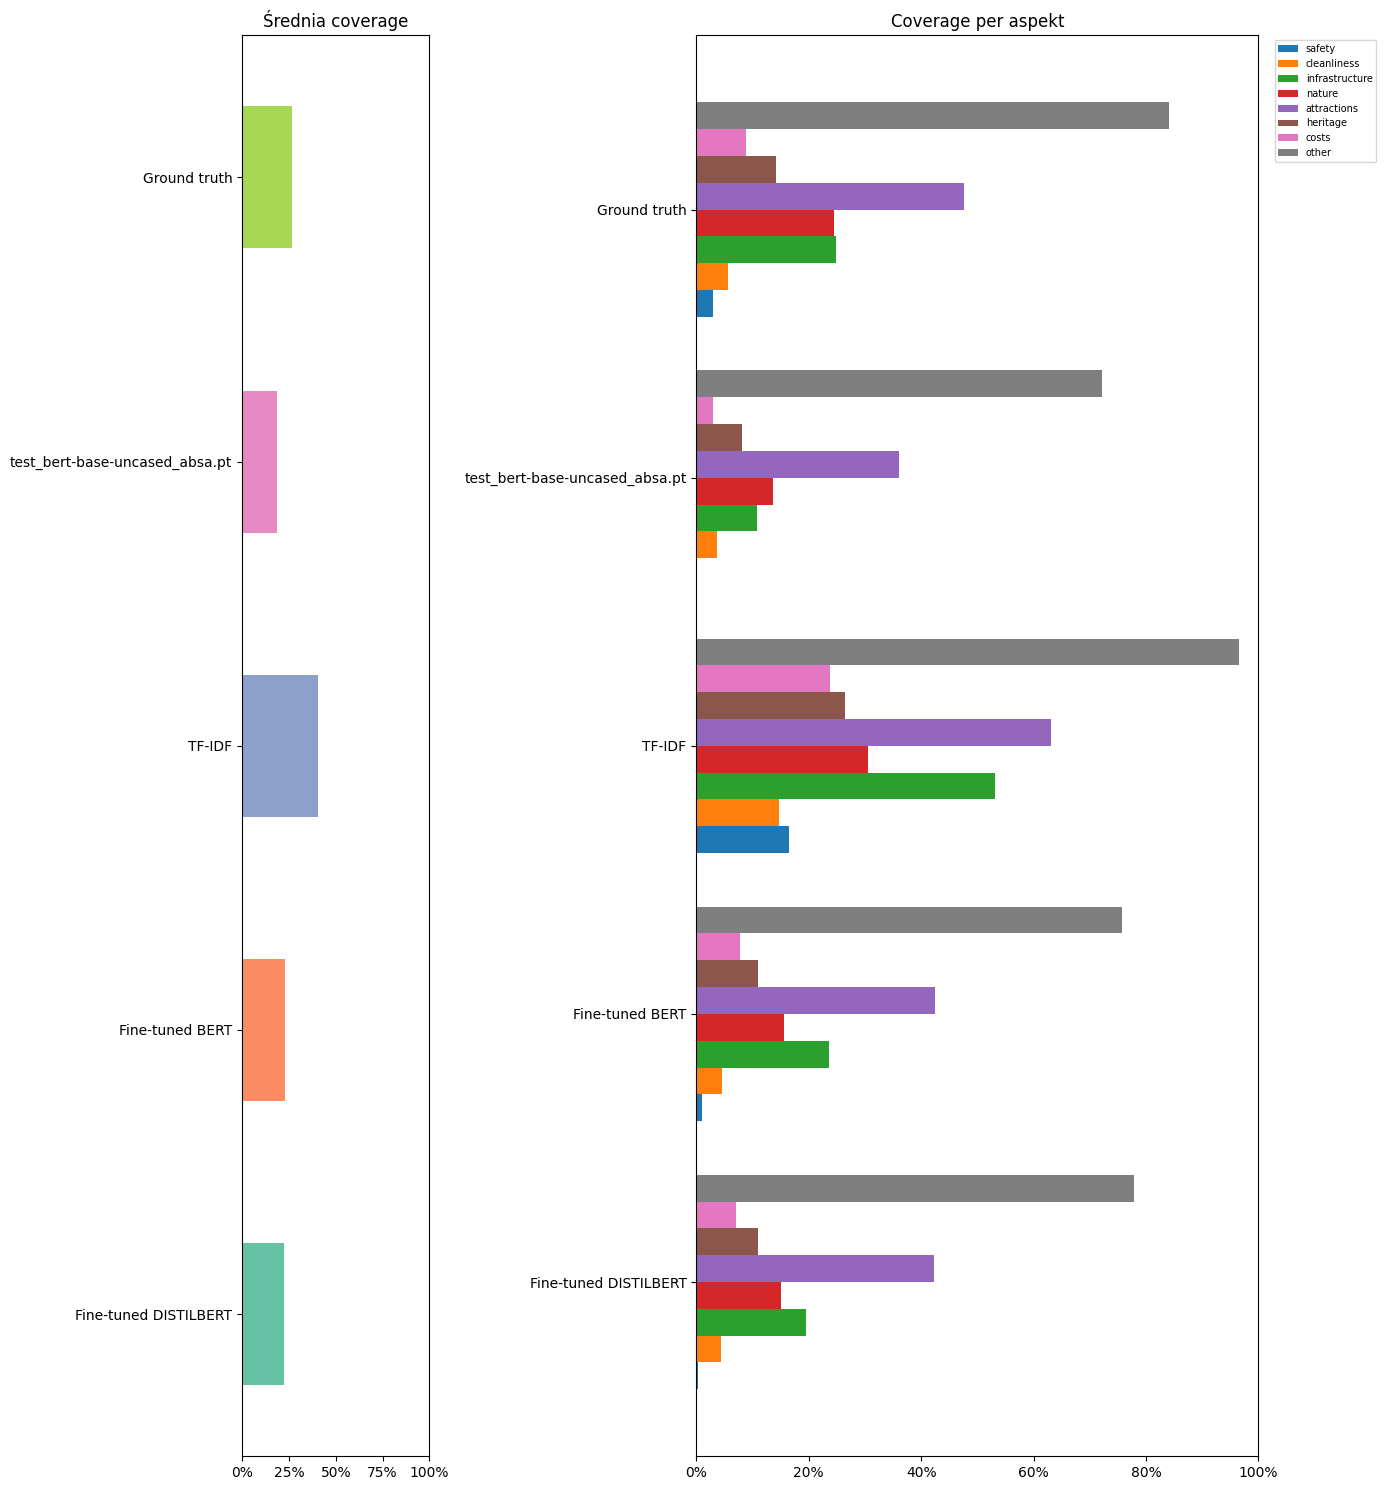

In [13]:
cov = pd.DataFrame(
    {n: {a: (p[a] != "notmentioned").mean() for a in ASPECTS} for n, p in preds.items()}
    | {"Ground truth": {a: (gt[a] != "notmentioned").mean() for a in ASPECTS}}
).T

fig, axes = plt.subplots(1, 2, figsize=(14, max(len(cov) * 3.0, 3)),
                          gridspec_kw={"width_ratios": [1, 3]})

cov.mean(axis=1).plot.barh(ax=axes[0], color=sns.color_palette("Set2", len(cov)))
axes[0].set_xlim(0, 1)
axes[0].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].set_title("Średnia coverage")

cov.plot.barh(ax=axes[1], width=0.8)
axes[1].set_xlim(0, 1)
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].set_title("Coverage per aspekt")
axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7)
plt.tight_layout()
plt.show()

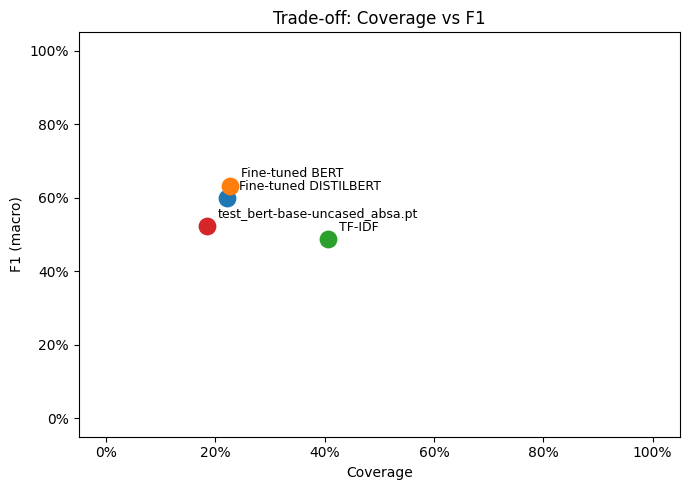

In [14]:
fig, ax = plt.subplots(figsize=(7, 5))
for name in preds:
    yt, yp = flat(gt), flat(preds[name])
    f1 = f1_score(yt, yp, labels=SENTIMENT_LABELS, average="macro", zero_division=0)
    c = (yp != "notmentioned").mean()
    ax.scatter(c, f1, s=140, zorder=5)
    ax.annotate(name, (c, f1), textcoords="offset points", xytext=(8, 6), fontsize=9)

ax.set_xlabel("Coverage")
ax.set_ylabel("F1 (macro)")

ax.set_title("Trade-off: Coverage vs F1")

# Pokazanie wykresu w zakresie 0-1 z 0.05 przesunięciem
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)

ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.tight_layout()
plt.show()

## 5. Macierze pomyłek (Confusion Matrices)

Macierz pomyłek dla każdej metody, zagregowana po wszystkich aspektach. Kolory odpowiadają proporcji wierszowej (recall per klasa), liczby to wartości bezwzględne.

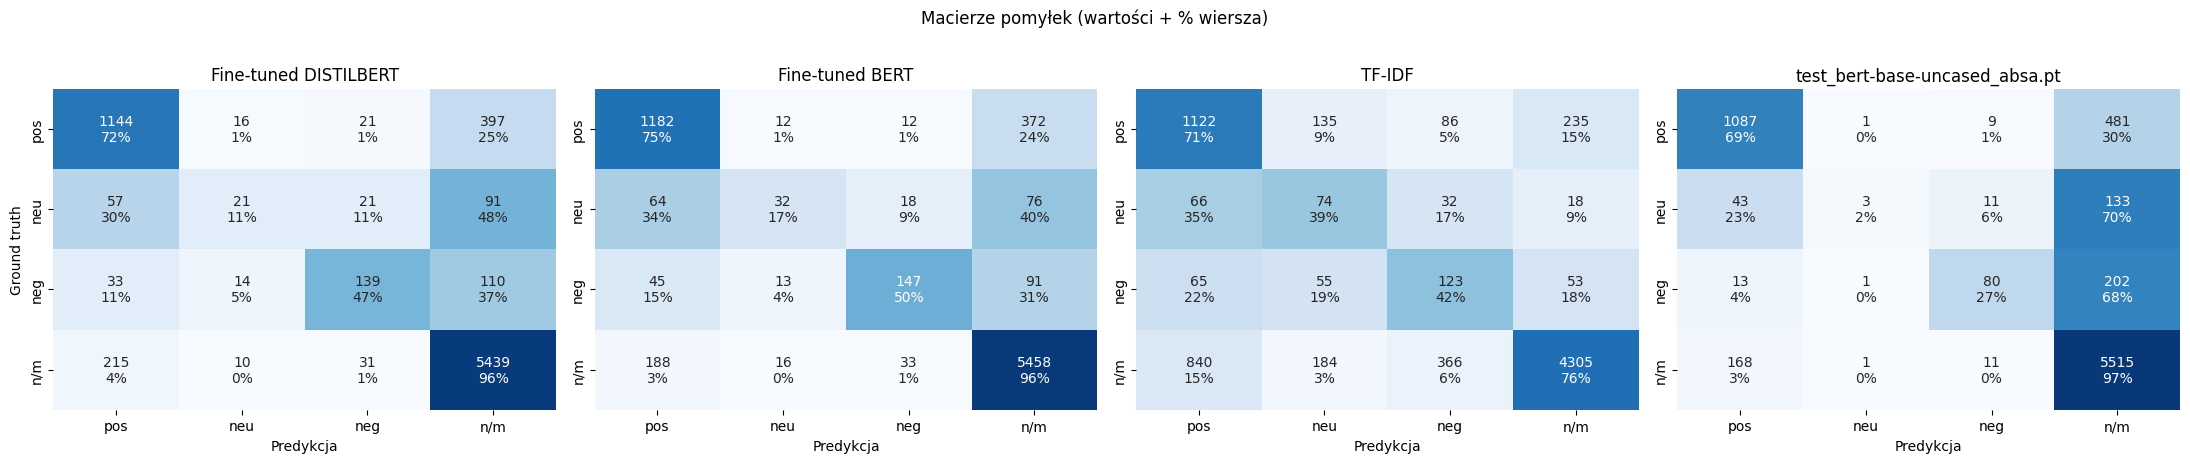

In [15]:
from sklearn.metrics import confusion_matrix


n_methods = len(preds)
fig, axes = plt.subplots(1, n_methods, figsize=(5.5 * n_methods, 4.5))
if n_methods == 1:
    axes = [axes]

short = ["pos", "neu", "neg", "n/m"]

for ax, (name, p) in zip(axes, preds.items()):
    yt, yp = flat(gt), flat(p)
    cm = confusion_matrix(yt, yp, labels=SENTIMENT_LABELS)
    row_sums = cm.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    cm_norm = cm / row_sums

    annot = np.array([
        [f"{v}\n{pct:.0%}" for v, pct in zip(r, rn)]
        for r, rn in zip(cm, cm_norm)
    ])

    sns.heatmap(
        cm_norm, annot=annot, fmt="", cmap="Blues",
        xticklabels=short, yticklabels=short,
        ax=ax, vmin=0, vmax=1, cbar=False,
    )
    ax.set_title(name)
    ax.set_ylabel("Ground truth" if ax is axes[0] else "")
    ax.set_xlabel("Predykcja")

plt.suptitle("Macierze pomyłek (wartości + % wiersza)", y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

### Macierz kosztów błędów (asymetryczna ważność pomyłek)

Standardowa macierz pomyłek traktuje każdy błąd tak samo. Poniżej stosujemy **macierz kosztów** \(C(\text{prawda}, \text{pred})\) zgodną z intencją: **najcięższy** jest błąd **biegunowy** (np. prawda `positive`, pred `negative` lub odwrotnie); **łagodniejszy** jest błąd „zgubienia” sentymentu na rzecz `notmentioned`; **umiarkowany** — pomyłka `positive` ↔ `neutral` (bliski sentyment bez odwrócenia bieguna). Dla `notmentioned` przypisanie dowolnego sentymentu ma jednakowy umiarkowany koszt („fałszywa aktywacja aspektu”).

Wartości są **względne** (skala 0–10); do porównania metod służy **średni koszt na jedną etykietę** (aspekt × recenzja) oraz heatmapa **\(C_{ij} \cdot \text{licznik}_{ij}\)** — suma po wszystkich komórkach to łączny „koszt zbioru”.

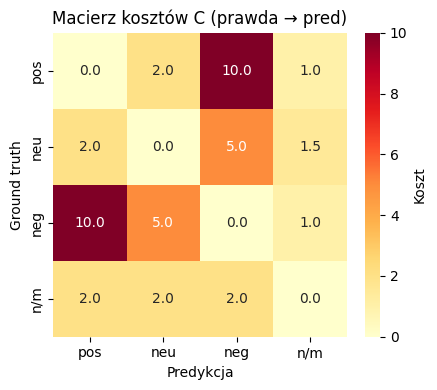

,średni koszt / etykietę,suma kosztów
Metoda,,
Fine-tuned DISTILBERT,0.2599,2016.5000
Fine-tuned BERT,0.2485,1928.0000
TF-IDF,0.7014,5442.0000
test_bert-base-uncased_absa.pt,0.2076,1610.5000


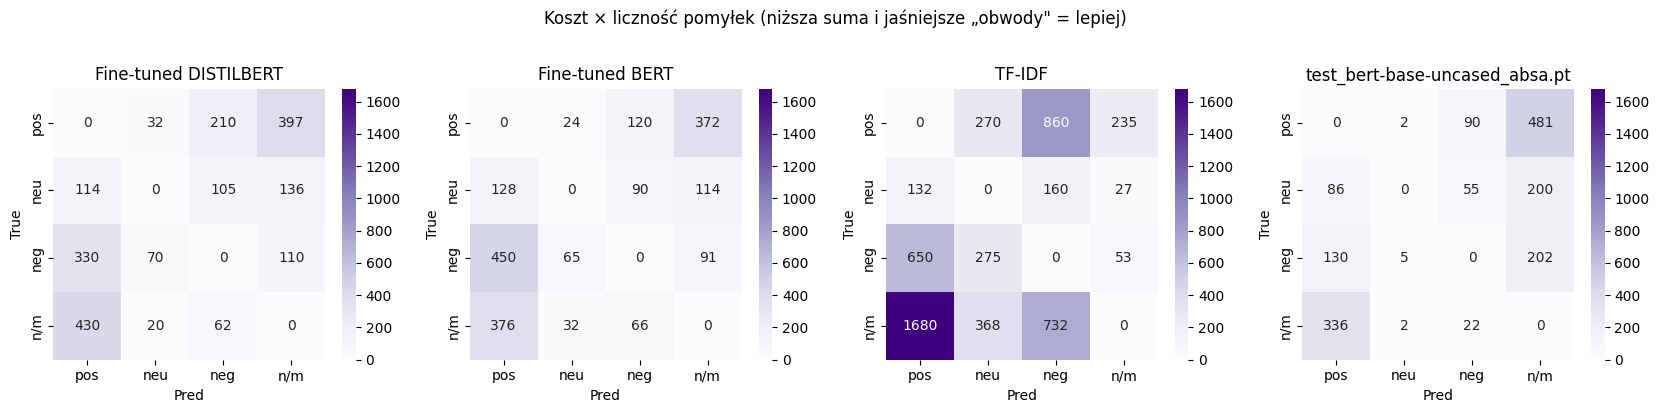

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.metrics import confusion_matrix

# Zgodnie z SENTIMENT_LABELS: positive, neutral, negative, notmentioned
SHORT = ["pos", "neu", "neg", "n/m"]

# C[i,j] = koszt gdy prawda = i, predykcja = j (0 na diagonali).
# Skala względna: biegun pos↔neg = 10; pos↔neu = 2 (łagodniej); pos→n/m = 1;
# neu↔neg = 5 (gorsze niż do neutralnego sąsiedztwa, bez pełnego bieguna pos-neg);
# prawda n/m → sentyment = 2 (fałszywa wzmianka).
C = np.array(
    [
        [0.0, 2.0, 10.0, 1.0],
        [2.0, 0.0, 5.0, 1.5],
        [10.0, 5.0, 0.0, 1.0],
        [2.0, 2.0, 2.0, 0.0],
    ],
    dtype=float,
)
assert C.shape == (len(SENTIMENT_LABELS), len(SENTIMENT_LABELS))

fig_c, ax_c = plt.subplots(figsize=(4.5, 4))
sns.heatmap(
    C,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    xticklabels=SHORT,
    yticklabels=SHORT,
    vmin=0,
    vmax=10,
    ax=ax_c,
    cbar_kws={"label": "Koszt"},
)
ax_c.set_xlabel("Predykcja")
ax_c.set_ylabel("Ground truth")
ax_c.set_title("Macierz kosztów C (prawda → pred)")
plt.tight_layout()
plt.show()

rows_cost = []
weighted_mats: dict[str, np.ndarray] = {}

for name, p in preds.items():
    yt, yp = flat(gt), flat(p)
    cm = confusion_matrix(yt, yp, labels=SENTIMENT_LABELS).astype(float)
    w = C * cm
    total = int(cm.sum())
    rows_cost.append(
        {
            "Metoda": name,
            "średni koszt / etykietę": w.sum() / total if total else 0.0,
            "suma kosztów": w.sum(),
        }
    )
    weighted_mats[name] = w

display(pd.DataFrame(rows_cost).set_index("Metoda").style.format("{:.4f}"))

n_m = len(preds)
fig_w, axes_w = plt.subplots(1, n_m, figsize=(4.2 * n_m, 4))
if n_m == 1:
    axes_w = [axes_w]
vmax = max(w.max() for w in weighted_mats.values()) or 1.0
for ax_w, (name, w) in zip(axes_w, weighted_mats.items()):
    sns.heatmap(
        w,
        annot=True,
        fmt=".0f",
        cmap="Purples",
        xticklabels=SHORT,
        yticklabels=SHORT,
        ax=ax_w,
        vmin=0,
        vmax=vmax,
        cbar=True,
    )
    ax_w.set_title(name)
    ax_w.set_xlabel("Pred")
    ax_w.set_ylabel("True")
plt.suptitle("Koszt × liczność pomyłek (niższa suma i jaśniejsze „obwody\" = lepiej)", y=1.02)
plt.tight_layout()
plt.show()